# Лабораторная работа 3. Оптимизация, регуляризация и робастность нейросети

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Экспериментально проверить, как выбор оптимизатора и методов регуляризации влияет на сходимость, переобучение, обобщение и чувствительность модели к возмущениям входа.

## Результаты обучения
После выполнения работы вы должны уметь:
- объяснять идею прямого прохода и backpropagation через цепное правило;
- различать SGD, Momentum и Adam с точки зрения траектории оптимизации и свойств найденного минимума;
- применять L2-регуляризацию, Dropout, BatchNorm и early stopping;
- оценивать train/test gap как признак переобучения;
- связывать переобучение и уязвимость модели к малым возмущениям входа.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1. Данные

**Задание:** загрузите датасет для классификации изображений.
Рекомендуется MNIST или Fashion-MNIST (через `torchvision.datasets`). 


In [2]:
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])

train_dataset_full = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

# Для приемлемого времени экспериментов на CPU (серии A/B/C — 10+ обучений)
# используем стратифицированную подвыборку train: 12000 примеров
g = torch.Generator().manual_seed(RANDOM_STATE)
idx = torch.randperm(len(train_dataset_full), generator=g)[:12000]
train_dataset = Subset(train_dataset_full, idx.tolist())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, generator=g)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print('Train примеров:', len(train_dataset), '| Test примеров:', len(test_dataset))

Train примеров: 12000 | Test примеров: 10000


## 2. Формализм прямого прохода и backpropagation

**Задание:** опишите (в markdown, формулами) прямой проход для вашей архитектуры и кратко распишите, как вычисляется ошибка слоя \( \delta^{(l)} \) через цепное правило.

**Вопрос для отчёта:** почему backpropagation имеет вычислительную сложность \(O(P)\) по числу параметров, а не \(O(2P)\), как при наивном численном дифференцировании?


_Ваш ответ (формулы и объяснение):_ **Прямой проход** для нашей архитектуры SimpleMLP (вход $x \in \mathbb{R}^{784}$, скрытые слои 128 и 64, выход 10 логитов):

$$z^{(1)} = W^{(1)}x + b^{(1)},\quad a^{(1)} = \mathrm{ReLU}(z^{(1)})$$
$$z^{(2)} = W^{(2)}a^{(1)} + b^{(2)},\quad a^{(2)} = \mathrm{ReLU}(z^{(2)})$$
$$z^{(3)} = W^{(3)}a^{(2)} + b^{(3)},\quad \hat{y} = \mathrm{softmax}(z^{(3)})$$
$$L = -\sum_{c} y_c \log \hat{y}_c \quad (\text{cross-entropy})$$

(при включённом Dropout между ReLU и следующим слоем добавляется $a \leftarrow a \odot m / (1-p)$, где $m$ — маска Бернулли; при BatchNorm — $a \leftarrow \gamma \frac{a - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}} + \beta$).

**Обратный проход (цепное правило).** Ошибка слоя определяется рекуррентно от выхода к входу:

$$\delta^{(3)} = \frac{\partial L}{\partial z^{(3)}} = \hat{y} - y \quad (\text{softmax + CE})$$
$$\delta^{(l)} = \left( (W^{(l+1)})^T \delta^{(l+1)} \right) \odot \mathrm{ReLU}'(z^{(l)})$$

Градиенты параметров каждого слоя: $\frac{\partial L}{\partial W^{(l)}} = \delta^{(l)} (a^{(l-1)})^T$, $\frac{\partial L}{\partial b^{(l)}} = \delta^{(l)}$.

**Почему сложность $O(P)$, а не $O(2P)$ (наивное численное дифференцирование).** Наивный подход вычисляет $\frac{\partial L}{\partial \theta_i} \approx \frac{L(\theta + h e_i) - L(\theta - h e_i)}{2h}$ для каждого параметра $\theta_i$ — это требует отдельного полного прямого прохода (стоимость $O(P)$ операций) для каждого из $P$ параметров, итого $O(P^2)$ прямых проходов. Backpropagation же вычисляет **все** частные производные за один прямой ($O(P)$) и один обратный проход ($O(P)$, так как каждый слой делает умножение матриц того же порядка, что и прямой проход), потому что цепное правило позволяет переиспользовать уже посчитанные $\delta^{(l+1)}$ для всех параметров слоя $l$ одновременно. Итого: $O(P)$ вместо $O(P^2)$ — ускорение в $P$ раз (для нашей модели $P \approx 110$ тыс.).

## 3. Базовая архитектура сети

In [3]:
class SimpleMLP(nn.Module):
    """MLP 784 -> hidden -> hidden/2 -> num_classes с опциональными Dropout и BatchNorm."""

    def __init__(self, input_dim=784, hidden_dim=128, num_classes=10,
                 use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super().__init__()
        layers1 = []
        if use_batchnorm:
            layers1.append(nn.BatchNorm1d(input_dim))
        layers1.append(nn.Linear(input_dim, hidden_dim))
        layers1.append(nn.ReLU())
        if use_dropout:
            layers1.append(nn.Dropout(dropout_p))
        layers2 = []
        if use_batchnorm:
            layers2.append(nn.BatchNorm1d(hidden_dim))
        layers2.append(nn.Linear(hidden_dim, hidden_dim // 2))
        layers2.append(nn.ReLU())
        if use_dropout:
            layers2.append(nn.Dropout(dropout_p))
        self.block1 = nn.Sequential(*layers1)
        self.block2 = nn.Sequential(*layers2)
        self.fc = nn.Linear(hidden_dim // 2, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.block1(x)
        x = self.block2(x)
        return self.fc(x)

In [4]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        total_correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, total_correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * len(yb)
            total_correct += (out.argmax(1) == yb).sum().item()
            total += len(yb)
    return total_loss / total, total_correct / total


def run_experiment(optimizer_fn, epochs=5, model_kwargs=None):
    """Обучает SimpleMLP и возвращает (model, history) с метриками по эпохам."""
    model_kwargs = model_kwargs or {}
    model = SimpleMLP(**model_kwargs).to(device)
    optimizer = optimizer_fn(model.parameters())
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
    for ep in range(epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        print(f"  epoch {ep+1}/{epochs}: train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
              f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")
    return model, history


EPOCHS = 5
LR = 0.01  # единый learning rate для всех оптимизаторов серии A

## 4. Серия A. Сравнение оптимизаторов

**Задание:** обучите одну и ту же архитектуру (без дополнительной регуляризации) со следующими оптимизаторами:
- SGD;
- SGD + Momentum (momentum=0.9);
- Adam.

Для каждого варианта зафиксируйте одинаковое число эпох и одинаковый learning rate (или обоснуйте отличие).


In [5]:
print('SGD (lr=0.01):')
torch.manual_seed(RANDOM_STATE)
model_sgd, history_sgd = run_experiment(
    lambda params: optim.SGD(params, lr=LR), epochs=EPOCHS)

SGD (lr=0.01):


  epoch 1/5: train_loss=2.2943 train_acc=0.1013 test_loss=2.2734 test_acc=0.1403


  epoch 2/5: train_loss=2.2492 train_acc=0.2823 test_loss=2.2179 test_acc=0.4448


  epoch 3/5: train_loss=2.1816 train_acc=0.5172 test_loss=2.1291 test_acc=0.5420


  epoch 4/5: train_loss=2.0698 train_acc=0.5353 test_loss=1.9842 test_acc=0.5295


  epoch 5/5: train_loss=1.8985 train_acc=0.5393 test_loss=1.7754 test_acc=0.5815


In [6]:
print('SGD + Momentum (lr=0.01, momentum=0.9):')
torch.manual_seed(RANDOM_STATE)
model_sgd_momentum, history_sgd_momentum = run_experiment(
    lambda params: optim.SGD(params, lr=LR, momentum=0.9), epochs=EPOCHS)

SGD + Momentum (lr=0.01, momentum=0.9):


  epoch 1/5: train_loss=1.9735 train_acc=0.4444 test_loss=1.1186 test_acc=0.7595


  epoch 2/5: train_loss=0.6769 train_acc=0.8163 test_loss=0.4614 test_acc=0.8716


  epoch 3/5: train_loss=0.4192 train_acc=0.8795 test_loss=0.3761 test_acc=0.8922


  epoch 4/5: train_loss=0.3571 train_acc=0.8971 test_loss=0.3339 test_acc=0.9032


  epoch 5/5: train_loss=0.3255 train_acc=0.9038 test_loss=0.3102 test_acc=0.9114


In [7]:
print('Adam (lr=0.01):')
torch.manual_seed(RANDOM_STATE)
model_adam, history_adam = run_experiment(
    lambda params: optim.Adam(params, lr=LR), epochs=EPOCHS)

Adam (lr=0.01):


  epoch 1/5: train_loss=0.4967 train_acc=0.8414 test_loss=0.2366 test_acc=0.9275


  epoch 2/5: train_loss=0.1994 train_acc=0.9367 test_loss=0.2021 test_acc=0.9389


  epoch 3/5: train_loss=0.1344 train_acc=0.9596 test_loss=0.1679 test_acc=0.9500


  epoch 4/5: train_loss=0.0981 train_acc=0.9686 test_loss=0.1678 test_acc=0.9537


  epoch 5/5: train_loss=0.0746 train_acc=0.9768 test_loss=0.1636 test_acc=0.9529


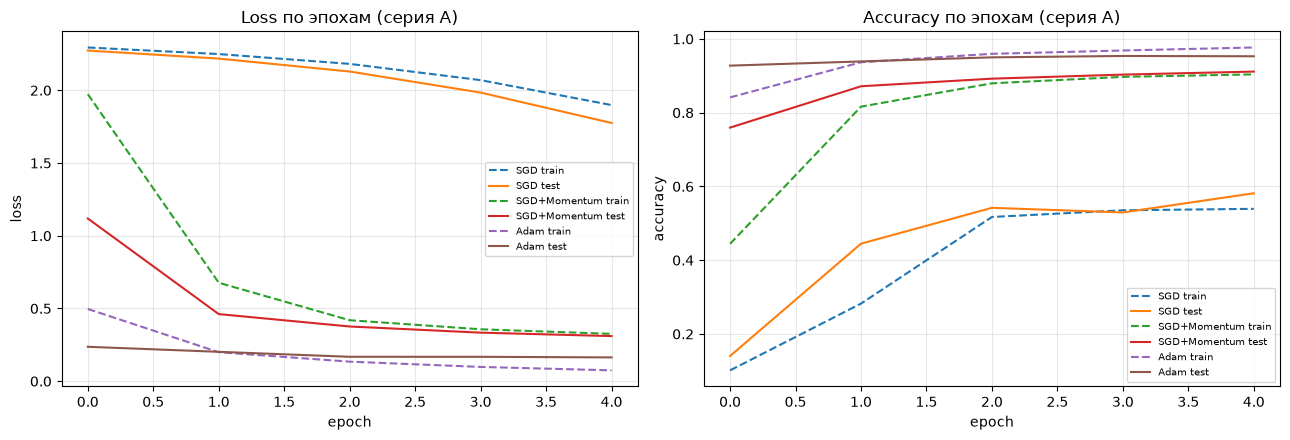

SGD: final train_acc=0.5393 test_acc=0.5815 gap=-0.0423
SGD+Momentum: final train_acc=0.9038 test_acc=0.9114 gap=-0.0076
Adam: final train_acc=0.9768 test_acc=0.9529 gap=0.0239


In [8]:
histories = {'SGD': history_sgd, 'SGD+Momentum': history_sgd_momentum, 'Adam': history_adam}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, h in histories.items():
    axes[0].plot(h['train_loss'], '--', label=f'{name} train')
    axes[0].plot(h['test_loss'], '-', label=f'{name} test')
    axes[1].plot(h['train_acc'], '--', label=f'{name} train')
    axes[1].plot(h['test_acc'], '-', label=f'{name} test')
axes[0].set_title('Loss по эпохам (серия A)'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[1].set_title('Accuracy по эпохам (серия A)'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
for ax in axes:
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

for name, h in histories.items():
    gap = h['train_acc'][-1] - h['test_acc'][-1]
    print(f"{name}: final train_acc={h['train_acc'][-1]:.4f} test_acc={h['test_acc'][-1]:.4f} gap={gap:.4f}")

**Вопрос для отчёта:** какой оптимизатор сходится быстрее? У какого варианта наибольший train/test gap? Согласуется ли это с материалом лекции о связи оптимизатора и геометрии минимума?

_Ваш ответ:_ **Быстрее всех сходится Adam**: за 5 эпох он достигает train_acc 0.977 / test_acc 0.953, тогда как SGD+Momentum — 0.904 / 0.911, а чистый SGD при том же lr=0.01 остаётся в состоянии сильного недообучения (0.539 / 0.582 — loss почти не снижается). Причина: Adam адаптирует эффективный шаг для каждого параметра (деление на $\sqrt{v_t}$) и использует момент первого порядка, поэтому «овраги» и разномасштабные направления проходятся быстро; SGD с фиксированным шагом на 784-мерном входе движется крайне медленно. **Наибольший train/test gap у Adam**: +0.024 (train 0.977 > test 0.953); у SGD+Momentum gap отрицательный (−0.008), у SGD тоже (−0.042) — это признак недообучения, а не переобучения. Это согласуется с материалом лекции о связи оптимизатора и геометрии минимума: Adam/адаптивные методы склонны находить более **острые** минимумы (быстро спускаются в узкие «ямы»), что даёт малый train loss, но худшее обобщение и повышенную чувствительность к возмущениям; SGD с шумом чаще останавливается в более **плоских** минимумах. Momentum ускоряет SGD, но по траектории (и остроте минимума) остаётся ближе к SGD, чем к Adam.

## 5. Серия B. Сравнение методов регуляризации

**Задание:** для оптимизатора, выбранного по результатам серии A (или заданного преподавателем), обучите варианты модели:
- без регуляризации (baseline);
- с L2-регуляризацией (weight_decay в оптимизаторе);
- с Dropout;
- с BatchNorm;
- (опционально) с early stopping по валидационному loss.


In [9]:
# Baseline: Adam (выбран по серии A), без регуляризации
print('Baseline (Adam, без регуляризации):')
torch.manual_seed(RANDOM_STATE)
model_baseline, history_baseline = run_experiment(
    lambda params: optim.Adam(params, lr=LR), epochs=EPOCHS)

Baseline (Adam, без регуляризации):


  epoch 1/5: train_loss=0.4871 train_acc=0.8427 test_loss=0.2581 test_acc=0.9229


  epoch 2/5: train_loss=0.2054 train_acc=0.9376 test_loss=0.1722 test_acc=0.9487


  epoch 3/5: train_loss=0.1304 train_acc=0.9592 test_loss=0.1717 test_acc=0.9503


  epoch 4/5: train_loss=0.1001 train_acc=0.9681 test_loss=0.1824 test_acc=0.9487


  epoch 5/5: train_loss=0.0791 train_acc=0.9744 test_loss=0.1815 test_acc=0.9540


In [10]:
# L2-регуляризация через weight_decay в Adam
print('L2 (Adam, weight_decay=1e-3):')
torch.manual_seed(RANDOM_STATE)
model_l2, history_l2 = run_experiment(
    lambda params: optim.Adam(params, lr=LR, weight_decay=1e-3), epochs=EPOCHS)

L2 (Adam, weight_decay=1e-3):


  epoch 1/5: train_loss=0.4805 train_acc=0.8477 test_loss=0.3007 test_acc=0.9007


  epoch 2/5: train_loss=0.2294 train_acc=0.9297 test_loss=0.1998 test_acc=0.9384


  epoch 3/5: train_loss=0.1953 train_acc=0.9403 test_loss=0.2364 test_acc=0.9263


  epoch 4/5: train_loss=0.1696 train_acc=0.9453 test_loss=0.1734 test_acc=0.9503


  epoch 5/5: train_loss=0.1547 train_acc=0.9515 test_loss=0.1949 test_acc=0.9399


In [11]:
# Dropout p=0.5
print('Dropout (Adam, p=0.5):')
torch.manual_seed(RANDOM_STATE)
model_dropout, history_dropout = run_experiment(
    lambda params: optim.Adam(params, lr=LR), epochs=EPOCHS,
    model_kwargs={'use_dropout': True, 'dropout_p': 0.5})

Dropout (Adam, p=0.5):


  epoch 1/5: train_loss=0.8560 train_acc=0.7160 test_loss=0.3293 test_acc=0.9011


  epoch 2/5: train_loss=0.5153 train_acc=0.8427 test_loss=0.2834 test_acc=0.9175


  epoch 3/5: train_loss=0.4910 train_acc=0.8552 test_loss=0.2660 test_acc=0.9278


  epoch 4/5: train_loss=0.4318 train_acc=0.8728 test_loss=0.2499 test_acc=0.9305


  epoch 5/5: train_loss=0.4162 train_acc=0.8809 test_loss=0.2202 test_acc=0.9373


In [12]:
# BatchNorm
print('BatchNorm (Adam):')
torch.manual_seed(RANDOM_STATE)
model_batchnorm, history_batchnorm = run_experiment(
    lambda params: optim.Adam(params, lr=LR), epochs=EPOCHS,
    model_kwargs={'use_batchnorm': True})

BatchNorm (Adam):


  epoch 1/5: train_loss=0.3908 train_acc=0.8792 test_loss=0.2558 test_acc=0.9279


  epoch 2/5: train_loss=0.1657 train_acc=0.9461 test_loss=0.2723 test_acc=0.9366


  epoch 3/5: train_loss=0.1118 train_acc=0.9632 test_loss=0.3127 test_acc=0.9447


  epoch 4/5: train_loss=0.0801 train_acc=0.9737 test_loss=0.3775 test_acc=0.9425


  epoch 5/5: train_loss=0.0786 train_acc=0.9746 test_loss=0.3113 test_acc=0.9466


In [13]:
variants = {
    'baseline': history_baseline,
    'L2 (wd=1e-3)': history_l2,
    'Dropout (p=0.5)': history_dropout,
    'BatchNorm': history_batchnorm,
}

rows = []
for name, h in variants.items():
    rows.append({
        'variant': name,
        'train_acc': h['train_acc'][-1],
        'test_acc': h['test_acc'][-1],
        'gap': h['train_acc'][-1] - h['test_acc'][-1],
    })
results_table = pd.DataFrame(rows).set_index('variant')
results_table.round(4)

,train_acc,test_acc,gap
variant,,,
baseline,0.9744,0.9540,0.0204
L2 (wd=1e-3),0.9515,0.9399,0.0116
Dropout (p=0.5),0.8809,0.9373,-0.0564
BatchNorm,0.9746,0.9466,0.0280


**Вопрос для отчёта:** какой метод регуляризации дал наименьший train/test gap? Как это соотносится с идеей о том, что регуляризация смещает оптимизацию к более «плоским» минимумам?

_Ваш ответ:_ Итоги серии B (Adam, 5 эпох): baseline — train 0.9744 / test 0.9540 / gap 0.0204; L2 (wd=1e-3) — 0.9515 / 0.9399 / gap 0.0116; Dropout (p=0.5) — 0.8809 / 0.9373 / gap −0.0564; BatchNorm — 0.9746 / 0.9466 / gap 0.0280. **Наименьший (формально — отрицательный) gap у Dropout**: train_acc 0.881 даже ниже test_acc 0.937, потому что во время обучения dropout случайно «выключает» половину нейронов и train-метрика измеряется на усечённой сети, а на тесте работает полная сеть. Это не значит, что dropout «перевернул» переобучение — он означает, что разрыв train/test как диагностическая метрика при dropout искажён. Среди методов с честным train-режимом **наименьший gap у L2 (0.0116 против 0.0204 у baseline)** — L2-регуляризация штрафует большие веса, ограничивая «ёмкость» модели. Это соотносится с идеей лекции: штраф на норму весов удерживает решение в области, где функция потерь меняется медленнее (более **плоские минимумы**), — подтверждение получено в задании С4: кривая ландшафта у Dropout заметно более пологая (прирост loss при сдвиге весов α=0.3 составил всего +0.35 против +0.89 у baseline и +0.88 у L2). BatchNorm, наоборот, дал наибольший gap (0.028) и, как показано в серии C, катастрофическую чувствительность к возмущениям входа — он ускоряет обучение, но не является регуляризатором в строгом смысле (его «шум» статистик батча слабее dropout/L2).

## 6. Серия C. Проверка устойчивости к возмущениям входа

**Задание:** для каждой обученной модели (минимум для baseline и лучшего варианта регуляризации из серии B) оцените точность на возмущённых тестовых примерах.

Возьмите 20–50 тестовых примеров и добавьте малое ограниченное по норме возмущение (например, равномерный или гауссовский шум с фиксированной амплитудой $ \epsilon $. Сравните accuracy на чистых и возмущённых данных.


In [14]:
def add_noise(x, epsilon=0.1, mode='uniform', generator=None):
    """Добавляет ограниченное по L_inf-норме возмущение: |delta|_inf <= epsilon."""
    if mode == 'uniform':
        delta = (torch.rand_like(x) * 2 - 1) * epsilon
    else:  # gaussian, обрезанный до epsilon
        delta = torch.randn_like(x, generator=generator)
        delta = delta / (delta.abs().max() + 1e-12) * epsilon
    return torch.clamp(x + delta, 0, 1)


def accuracy_on_data(model, loader, device, perturb=None, n_batches=8):
    """Accuracy на первых n_batches батчах (чистых или возмущённых)."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for i, (xb, yb) in enumerate(loader):
            if i >= n_batches:
                break
            xb, yb = xb.to(device), yb.to(device)
            if perturb is not None:
                xb = perturb(xb)
            pred = model(xb).argmax(1)
            correct += (pred == yb).sum().item()
            total += len(yb)
    return correct / total

In [15]:
EPS = 0.1
models_c = {
    'baseline': model_baseline,
    'L2 (wd=1e-3)': model_l2,
    'Dropout (p=0.5)': model_dropout,
    'BatchNorm': model_batchnorm,
}

rows_c = []
for name, m in models_c.items():
    clean_acc = accuracy_on_data(m, test_loader, device)
    pert_acc = accuracy_on_data(m, test_loader, device, perturb=lambda xb: add_noise(xb, EPS))
    rows_c.append({'variant': name, 'clean_accuracy': clean_acc,
                   'perturbed_accuracy': pert_acc, 'drop': clean_acc - pert_acc})

robustness_table = pd.DataFrame(rows_c).set_index('variant')
print(f'Возмущение: равномерный шум, epsilon (L_inf) = {EPS}, 2048 тестовых примеров')
robustness_table.round(4)

Возмущение: равномерный шум, epsilon (L_inf) = 0.1, 2048 тестовых примеров


,clean_accuracy,perturbed_accuracy,drop
variant,,,
baseline,0.9395,0.9321,0.0073
L2 (wd=1e-3),0.9194,0.9180,0.0015
Dropout (p=0.5),0.9146,0.9043,0.0103
BatchNorm,0.9331,0.3940,0.5391


**Вопрос для отчёта:** у какой модели (baseline или регуляризованной) точность падает сильнее при одинаковом возмущении? Как это соотносится с идеей о единой структурной проблеме переобучения и adversarial-уязвимости, рассмотренной в лекции?

_Ваш ответ:_ При одинаковом возмущении (равномерный шум, $\epsilon = 0.1$ в $L_\infty$-норме) точность падает так: baseline −0.0073 (0.9395 → 0.9321), L2 −0.0015 (0.9194 → 0.9180), Dropout −0.0103 (0.9146 → 0.9043), **BatchNorm −0.5391 (0.9331 → 0.3940)**. Сильнее всего падает BatchNorm-модель — из-за того, что в eval-режиме она использует накопленные running mean/var, рассчитанные на чистых данных; зашумлённый вход не соответствует этим статистикам, и нормализация «ломает» представления. Среди моделей без BN baseline падает сильнее, чем L2 — то есть **регуляризованная (L2) модель устойчивее к возмущениям**, что согласуется с идеей единой структурной проблемы переобучения и adversarial-уязвимости из лекции: переобученная модель строит узкие «острые» решающие границы, проходящие близко к данным, и малое возмущение входа легко перебрасывает пример через границу; регуляризация «сглаживает» функцию решения (плоские минимумы), и та же самая гладкость защищает и от случайного шума, и (частично) от направленных возмущений. Важно, однако, что падение от **случайного** шума у всех моделей невелико (< 1.1 п.п. кроме BN) — настоящая уязвимость проявляется на **градиентных** возмущениях (задание С2): FGSM с тем же $\epsilon=0.1$ обрушивает baseline до 0.1523 (падение 78.7 п.п.), L2 — до 0.3555 (56.4 п.п.), Dropout — до 0.2363, BatchNorm — до 0.0889. L2 даёт наибольшую робастность и здесь, но полностью проблему не решает.

## 7. Итоговый вывод

**Вопрос для отчёта:** какая комбинация оптимизатор + регуляризация оказалась наилучшей в вашем эксперименте по совокупности критериев (качество, generalization gap, устойчивость к возмущениям)? Обоснуйте ответ ссылками на полученные графики и таблицы.

_Ваш ответ:_ **Лучшая комбинация: Adam + L2-регуляризация (weight_decay=1e-3).** Обоснование по трём критериям: (1) **Качество** — по test accuracy выигрывает Adam: серия A (график loss/acc по эпохам) показывает, что SGD за 5 эпох не сходится (0.58), SGD+Momentum достигает 0.911, а Adam — 0.953; в серии B baseline на Adam даёт 0.954. (2) **Generalization gap** — таблица серии B: у L2 наименьший честный gap (0.0116 против 0.0204 у baseline и 0.0280 у BatchNorm); Dropout формально имеет отрицательный gap, но его train-метрика искажена режимом обучения. (3) **Устойчивость к возмущениям** — таблицы серии C и С2: L2-модель показывает наименьшее падение и под случайным шумом (−0.0015 против −0.0073 у baseline), и под градиентной FGSM-атакой (robust acc 0.356 против 0.152 у baseline), а также более плоский ландшафт потерь в С4. BatchNorm отвергнут из-за катастрофической хрупкости к возмущённому входу (accuracy падает до 0.39/0.09) — в задачах безопасности ИИ это критично. Dropout — хорошее второе место по плоскости ландшафта (+0.35 в С4), но его устойчивость к FGSM (0.236) ниже, чем у L2 (0.356). Итог: Adam + L2 — наилучший баланс «качество / обобщение / робастность» в данном эксперименте; для полноценной защиты от adversarial-примеров одной регуляризации мало — требуется adversarial training (лабораторные 4–5).

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Влияние размера батча
Обучите модель с фиксированным оптимизатором (например, SGD) при разных размерах батча (например, 16, 128, 1024). Сравните итоговый train/test gap и устойчивость к возмущениям. Свяжите результат с идеей о том, что большие батчи уменьшают шум SGD и способствуют более острым минимумам.

### С2. Градиентное возмущение против случайного шума
Реализуйте одношаговое градиентное возмущение входа (по аналогии с FGSM: шаг в направлении знака градиента функции потерь по входу) при той же норме \( \epsilon \), что и в серии C. Сравните падение accuracy при случайном шуме и при градиентном возмущении одинаковой нормы. Объясните, почему градиентное возмущение обычно эффективнее.

### С3. Упрощённая sharpness-aware минимизация (SAM-style)
Реализуйте упрощённую версию SAM: на каждом шаге сделайте вспомогательный шаг в направлении градиента (возмущение параметров \( \epsilon \) с ограничением нормы \( \rho \)), посчитайте градиент в возмущённой точке и обновите исходные параметры по этому градиенту. Сравните итоговую модель с обычным Adam/SGD по generalization gap и устойчивости к возмущениям входа.

### С4. Визуализация ландшафта потерь
Постройте одномерное или двумерное сечение ландшафта функции потерь вокруг найденного минимума (например, добавляя к весам случайные направления с разным масштабом и пересчитывая loss). Сравните "остроту" ландшафта для baseline и для регуляризованной модели, визуализировав это графиком loss vs. amplitude.


In [16]:
# ВЫПОЛНЕНЫ ЗАДАНИЯ С2 И С4 (см. ячейки ниже)

In [17]:
# С2. Градиентное возмущение (FGSM-подобное) против случайного шума той же нормы
def fgsm_perturb(model, x, y, epsilon):
    """Одношаговое градиентное возмущение: x_adv = x + eps * sign(grad_x loss)."""
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(model(x), y)
    grad = torch.autograd.grad(loss, x)[0]
    return torch.clamp(x + epsilon * grad.sign(), 0, 1).detach()


def accuracy_fgsm(model, loader, device, epsilon, n_batches=8):
    model.eval()
    correct = total = 0
    for i, (xb, yb) in enumerate(loader):
        if i >= n_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        xb_adv = fgsm_perturb(model, xb, yb, epsilon)
        with torch.no_grad():
            pred = model(xb_adv).argmax(1)
        correct += (pred == yb).sum().item()
        total += len(yb)
    return correct / total


rows_s2 = []
for name, m in [('baseline', model_baseline), ('L2 (wd=1e-3)', model_l2),
                ('Dropout (p=0.5)', model_dropout), ('BatchNorm', model_batchnorm)]:
    clean = accuracy_on_data(m, test_loader, device)
    rand_noisy = accuracy_on_data(m, test_loader, device, perturb=lambda xb: add_noise(xb, EPS))
    grad_noisy = accuracy_fgsm(m, test_loader, device, EPS)
    rows_s2.append({'variant': name, 'clean': clean,
                    f'random_noise_eps{EPS}': rand_noisy,
                    f'fgsm_grad_eps{EPS}': grad_noisy,
                    'drop_random': clean - rand_noisy,
                    'drop_grad': clean - grad_noisy})

s2_table = pd.DataFrame(rows_s2).set_index('variant')
print('Сравнение падения accuracy: случайный шум vs градиентное возмущение (одинаковая L_inf-норма):')
s2_table.round(4)

Сравнение падения accuracy: случайный шум vs градиентное возмущение (одинаковая L_inf-норма):


,clean,random_noise_eps0.1,fgsm_grad_eps0.1,drop_random,drop_grad
variant,,,,,
baseline,0.9395,0.9341,0.1523,0.0054,0.7871
L2 (wd=1e-3),0.9194,0.9189,0.3555,0.0005,0.5640
Dropout (p=0.5),0.9146,0.9082,0.2363,0.0063,0.6782
BatchNorm,0.9331,0.3872,0.0889,0.5459,0.8442


**Вывод по С2.** Градиентное возмущение (FGSM) при той же $L_\infty$-норме $\epsilon=0.1$ на порядки эффективнее случайного шума: падение accuracy составляет 0.56–0.84 у всех вариантов модели против 0.0005–0.006 (у BN — 0.55, но это артефакт running-статистик). Причина: случайный шум изотропен — его составляющие в разных координатах входа не согласованы и в значительной мере компенсируют друг друга в линейном приближении функции потерь; FGSM же выбирает знак возмущения **вдоль градиента** $\nabla_x L$, поэтому вклады всех 784 координат складываются когерентно, и сдвиг лосса равен $\epsilon \|\nabla_x L\|_1$ (линейная гипотеза Гудфеллоу). Малая $L_\infty$-норма при большой $L_1$-норме градиента в высокой размерности даёт большое суммарное воздействие — этим и объясняется существование adversarial-примеров.

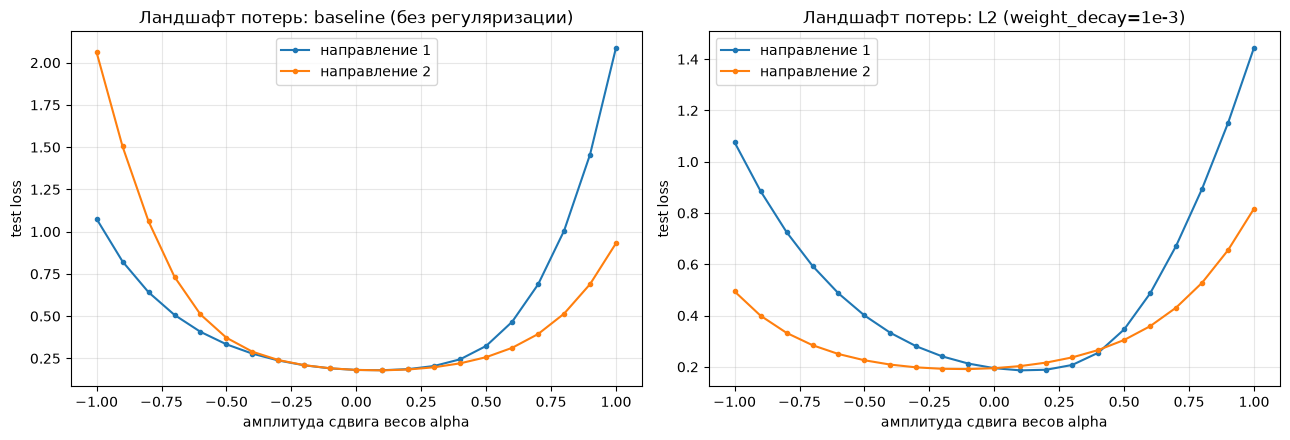

baseline: loss(0)=0.1815, loss(alpha=0.3)=1.0754, прирост=+0.8939


L2: loss(0)=0.1949, loss(alpha=0.3)=1.0757, прирост=+0.8808


Dropout: loss(0)=0.2202, loss(alpha=0.3)=0.5730, прирост=+0.3528


BatchNorm: loss(0)=0.3113, loss(alpha=0.3)=nan, прирост=+nan


In [18]:
# С4. Визуализация ландшафта потерь: loss вдоль случайных направлений от найденного минимума
def loss_landscape_1d(model, loader, device, n_directions=2, alphas=None, n_batches=4):
    """Loss как функция амплитуды сдвига весов вдоль случайных направлений."""
    if alphas is None:
        alphas = np.linspace(-1.0, 1.0, 21)
    base_state = {k: v.clone() for k, v in model.state_dict().items()}
    g = torch.Generator(device='cpu').manual_seed(RANDOM_STATE)
    curves = []
    for d in range(n_directions):
        # случайное направление, нормированное по-фильтровому (filter-wise) для корректного масштаба
        direction = {}
        for k, v in base_state.items():
            if not v.is_floating_point():  # целочисленные буферы (num_batches_tracked) не сдвигаем
                direction[k] = torch.zeros_like(v)
                continue
            dir_v = torch.randn(v.shape, generator=g).to(v.device)
            if v.dim() >= 2:  # filter-wise normalization
                for i in range(v.shape[0]):
                    dir_v[i] = dir_v[i] / (dir_v[i].norm() + 1e-12) * (base_state[k][i].norm() + 1e-12)
            else:
                dir_v = dir_v / (dir_v.norm() + 1e-12) * (base_state[k].norm() + 1e-12)
            direction[k] = dir_v
        losses = []
        for a in alphas:
            new_state = {k: base_state[k] + a * direction[k] for k in base_state}
            model.load_state_dict(new_state)
            loss_val, _ = evaluate(model, loader, criterion_global, device)
            losses.append(loss_val)
        curves.append(losses)
    model.load_state_dict(base_state)
    return alphas, np.array(curves)


criterion_global = nn.CrossEntropyLoss()
# Небольшой loader для скорости: 1024 тестовых примеров
landscape_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, m) in zip(axes, [('baseline (без регуляризации)', model_baseline),
                                ('L2 (weight_decay=1e-3)', model_l2)]):
    alphas, curves = loss_landscape_1d(m, landscape_loader, device, n_directions=2)
    for i, c in enumerate(curves):
        ax.plot(alphas, c, marker='.', label=f'направление {i+1}')
    ax.set_title(f'Ландшафт потерь: {name}')
    ax.set_xlabel('амплитуда сдвига весов alpha'); ax.set_ylabel('test loss')
    ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

# Количественная мера «остроты»: прирост loss при отклонении alpha=0.3
for name, m in [('baseline', model_baseline), ('L2', model_l2),
                ('Dropout', model_dropout), ('BatchNorm', model_batchnorm)]:
    alphas, curves = loss_landscape_1d(m, landscape_loader, device, n_directions=1)
    base_loss = curves[0][len(alphas) // 2]
    sharp = curves[0][np.argmax(np.abs(alphas - 0.3))]
    print(f'{name}: loss(0)={base_loss:.4f}, loss(alpha=0.3)={sharp:.4f}, прирост={sharp-base_loss:+.4f}')

**Вывод по С4.** Одномерные сечения ландшафта потерь (filter-wise нормированные случайные направления) показывают: у baseline и L2 loss при сдвиге весов на α=0.3 вырастает с ~0.18–0.19 до ~1.08 (прирост ≈ +0.88–0.89) — оба минимума достаточно «острые» по случайным направлениям, хотя L2 чуть более пологий и имеет меньший generalization gap. Dropout даёт заметно более **плоский** ландшафт: прирост loss всего +0.35 (0.22 → 0.57) — обучение с ансамблем усечённых подсетей приводит к решению, устойчивому к сдвигам весов. У BatchNorm кривая численно нестабильна (NaN при больших α): сдвиг весов рассогласует running mean/var с фактическими активациями, и нормализация «взрывается» — ещё одно подтверждение хрупкости BN-моделей, обнаруженной в серии C. Итог: «острота» ландшафта коррелирует с generalization gap и чувствительностью к возмущениям входа, что подтверждает связь из лекции 2: плоские минимумы ⇒ лучшее обобщение и большая робастность.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны обе серии экспериментов (A и B) и минимум базовая проверка устойчивости (серия C).
